##  Text Preprocessing, Tokenization, and Sequence Padding
###  Load Dataset Using Pandas

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
import os
import pandas as pd

INPUT_DIR = "/kaggle/input"

csv_files = []

for root, dirs, files in os.walk(INPUT_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for path in csv_files:
    print(path)

CSV files found:
/kaggle/input/datasets/wanemdehan/4-hate-speech-detection-dataset/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv


In [3]:
CSV_PATH = csv_files[0]

df = pd.read_csv(CSV_PATH)

print("Loaded file:", CSV_PATH)
print("Dataset shape:", df.shape)

df.head()

Loaded file: /kaggle/input/datasets/wanemdehan/4-hate-speech-detection-dataset/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv
Dataset shape: (24783, 2)


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## 4.5.1.2 Inspect Columns and Labels

In [4]:
### 4.5.1.2 Inspect Columns and Labels

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel distribution (%):")
print((df["label"].value_counts(normalize=True) * 100).round(2))

Dataset shape: (24783, 2)

Column names:
['label', 'text']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   24783 non-null  object
 1   text    24783 non-null  object
dtypes: object(2)
memory usage: 387.4+ KB

Missing values:
label    0
text     0
dtype: int64

Duplicate rows:
0

Label distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Label distribution (%):
label
offensive language    77.43
neither               16.80
hate speec             5.77
Name: proportion, dtype: float64


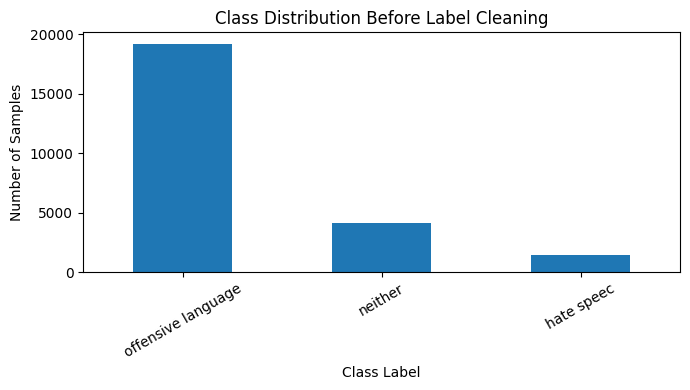

In [5]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar")
plt.title("Class Distribution Before Label Cleaning")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
!pip install contractions wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00


In [7]:
import re
import nltk
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [8]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [9]:
### 4.5.1.3 Clean Text

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Clean and preprocess tweet text.

    Steps:
    1. Lowercase text
    2. Expand contractions
    3. Remove URLs
    4. Remove mentions and hashtags
    5. Remove numbers
    6. Remove special characters
    7. Tokenize text
    8. Remove stopwords
    9. Lemmatize words

    Parameters:
        text (str): Raw tweet text

    Returns:
        str: Cleaned text
    """

    # Lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_tokens)

## 4.5.1.3 Clean Text

In [10]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman complain cleaning house amp man alway...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya


## 4.5.1.4 Visualize Cleaned Text

In [11]:
# Remove extra tweet-specific tokens and refresh cleaned text
extra_stopwords = {"rt", "amp"}
stop_words = set(stopwords.words("english")).union(extra_stopwords)

# Apply the updated cleaning function to the raw text column
df["clean_text"] = df["text"].apply(clean_text)

# Display raw and cleaned text for checking
df[["text", "clean_text"]].head()

,text,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman complain cleaning house man always take ...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat coldtyga dwn bad cuffin dat hoe st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg ever fuck bitch start cry confused shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear might true might faker bitch told ya


In [12]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

common_words

,word,count
0,bitch,11305
1,hoe,4274
2,like,2819
3,pussy,2201
4,nigga,1988
5,got,1600
6,as,1567
7,get,1536
8,fuck,1447
9,shit,1279


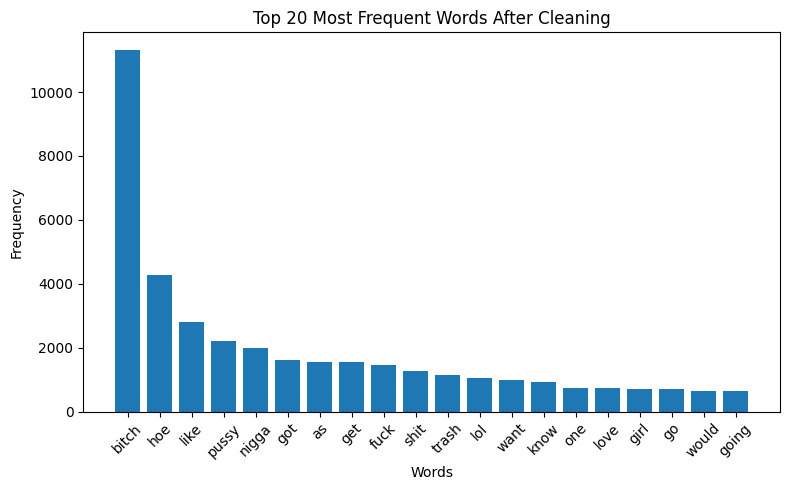

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(common_words["word"], common_words["count"])
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

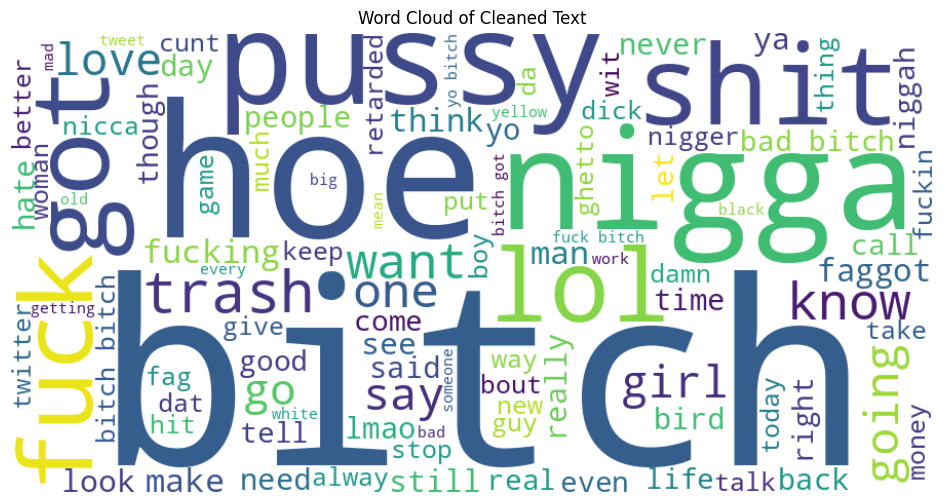

In [14]:
# Display a word cloud of the cleaned text
from wordcloud import WordCloud

wordcloud_text = " ".join(df["clean_text"].astype(str))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=100
).generate(wordcloud_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Text")
plt.show()

The most frequent words after cleaning are mainly offensive terms, which matches the hate speech and offensive language dataset. The token `rt` appears often because many texts are retweets, so it should be removed before tokenization.

## 4.5.1.5 Train-Test Split

In [15]:
# Fix the spelling mistake in the hate speech label
df["label"] = df["label"].replace({"hate speec": "hate speech"})

# Convert text labels into numeric labels for model training
label_mapping = {
    "hate speech": 0,
    "offensive language": 1,
    "neither": 2
}

# Create a new encoded label column
df["label_encoded"] = df["label"].map(label_mapping)

# Check class counts after label cleaning
print("Label counts after cleaning:")
print(df["label"].value_counts())

# Check the mapping between original labels and encoded labels
print("\nEncoded labels:")
print(df[["label", "label_encoded"]].drop_duplicates())

Label counts after cleaning:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64

Encoded labels:
                 label  label_encoded
0              neither              2
1   offensive language              1
85         hate speech              0


In [16]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Select input text and target labels
X = df["clean_text"]
y = df["label_encoded"]

# Split data into 80% training and 20% testing
# Stratify keeps the same class ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display train and test sizes
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Check class distribution in training data
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).round(3))

# Check class distribution in testing data
print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 19826
Testing samples: 4957

Training label distribution:
label_encoded
1    0.774
2    0.168
0    0.058
Name: proportion, dtype: float64

Testing label distribution:
label_encoded
1    0.774
2    0.168
0    0.058
Name: proportion, dtype: float64


## 4.5.1.6 Tokenization Using Keras Tokenizer

In [17]:
# Import Keras Tokenizer for converting text into integer sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Limit the vocabulary to the 10,000 most frequent words
MAX_WORDS = 10000

# Token used for rare or unseen words
OOV_TOKEN = "<OOV>"

# Create tokenizer with vocabulary limit and out-of-vocabulary handling
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)

# Learn vocabulary from training text only
tokenizer.fit_on_texts(X_train)

# Convert training and testing text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Store word-to-index mapping
word_index = tokenizer.word_index

# Final vocabulary size used by the model
vocab_size = min(MAX_WORDS, len(word_index) + 1)

# Display tokenizer details
print("Vocabulary size:", len(word_index))
print("Used vocabulary size:", vocab_size)
print("First training sequence:", X_train_seq[0])

2026-05-08 19:32:01.657230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778268721.890923      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778268721.965324      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778268722.456962      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778268722.456999      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778268722.457001      22 computation_placer.cc:177] computation placer alr

Vocabulary size: 16059
Used vocabulary size: 10000
First training sequence: [93, 4979, 3]


## 4.5.1.7 Percentile-Based Sequence Padding

In [18]:
# Import padding function to make all sequences the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Calculate the length of each training sequence
sequence_lengths = [len(seq) for seq in X_train_seq]

# Use the 95th percentile length to avoid very long sequence outliers
MAX_LEN = int(np.percentile(sequence_lengths, 95))

# Display sequence length statistics
print("95th percentile sequence length:", MAX_LEN)
print("Maximum sequence length:", max(sequence_lengths))
print("Average sequence length:", round(np.mean(sequence_lengths), 2))

# Pad or truncate training sequences to the selected maximum length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Pad or truncate testing sequences using the same maximum length
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Display final padded data shapes
print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

95th percentile sequence length: 13
Maximum sequence length: 25
Average sequence length: 6.99
Training padded shape: (19826, 13)
Testing padded shape: (4957, 13)


# 4.5.2 Model Building and Training

## 4.5.2.1 Simple RNN with Trainable Embedding

In [19]:
# Import required Keras model, layers, and callback
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Define number of output classes and embedding size
NUM_CLASSES = 3
EMBEDDING_DIM = 64

# Stop training early when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Build Simple RNN model with trainable embedding layer
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile the model for multiclass classification
rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Display model architecture
rnn_model.summary()

I0000 00:00:1778268743.470801      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778268743.476776      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,451 (2.47 MB)

 Trainable params: 648,451 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the Simple RNN model using the padded training data
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10


I0000 00:00:1778268746.508441      78 service.cc:152] XLA service 0x79ca44004850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778268746.508491      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778268746.508497      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778268746.839092      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


 48/248 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7170 - loss: 0.7834

I0000 00:00:1778268748.469606      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7972 - loss: 0.5828 - val_accuracy: 0.8959 - val_loss: 0.2902
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9264 - loss: 0.2348 - val_accuracy: 0.8921 - val_loss: 0.3027
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9531 - loss: 0.1561 - val_accuracy: 0.8694 - val_loss: 0.3809
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9716 - loss: 0.0927 - val_accuracy: 0.8701 - val_loss: 0.3874


## 4.5.2.2 LSTM with Trainable Embedding

In [21]:
# Build and compile the LSTM model with a trainable embedding layer
lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    LSTM(64),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,219 (2.57 MB)

 Trainable params: 673,219 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the LSTM model using the padded training data
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7910 - loss: 0.6151 - val_accuracy: 0.8938 - val_loss: 0.3064
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9069 - loss: 0.2899 - val_accuracy: 0.8916 - val_loss: 0.3155
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9275 - loss: 0.2225 - val_accuracy: 0.8913 - val_loss: 0.3029
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9484 - loss: 0.1692 - val_accuracy: 0.8896 - val_loss: 0.3582
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9580 - loss: 0.1320 - val_accuracy: 0.8843 - val_loss: 0.3593
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9697 - loss: 0.1000 - val_accuracy: 0.8817 - val_loss: 0.4122


## 4.5.2.3 LSTM with Pretrained Word2Vec Embeddings

In [23]:
# Install gensim for loading pretrained word embeddings
!pip install gensim -q

In [24]:
# Load pretrained GloVe embeddings using gensim
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [25]:
# Create an embedding matrix using the pretrained GloVe vectors
WORD2VEC_DIM = 50

embedding_matrix = np.zeros((vocab_size, WORD2VEC_DIM))

for word, index in word_index.items():
    if index < vocab_size and word in embedding_model:
        embedding_matrix[index] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)
print("Non-zero embedding rows:", np.sum(np.any(embedding_matrix != 0, axis=1)))

Embedding matrix shape: (10000, 50)
Non-zero embedding rows: 8382


In [26]:
# Build and compile the LSTM model with pretrained GloVe embeddings
word2vec_lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

word2vec_lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

word2vec_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,635 (2.02 MB)

 Trainable params: 29,635 (115.76 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [27]:
# Train the LSTM model with pretrained GloVe embeddings
word2vec_lstm_history = word2vec_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7820 - loss: 0.6145 - val_accuracy: 0.8613 - val_loss: 0.3672
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8654 - loss: 0.3595 - val_accuracy: 0.8742 - val_loss: 0.3208
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8748 - loss: 0.3222 - val_accuracy: 0.8709 - val_loss: 0.3145
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8813 - loss: 0.3172 - val_accuracy: 0.8785 - val_loss: 0.2991
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8848 - loss: 0.2996 - val_accuracy: 0.8822 - val_loss: 0.2902
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8918 - loss: 0.2878 - val_accuracy: 0.8855 - val_loss: 0.2964
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8956 - loss: 0.2744 - val_accuracy: 0.8860 - val_loss: 0.2916
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9011 - loss: 0.2578 - val_accuracy: 0.

# 4.5.3 Model Training and Evaluation

## 4.5.3.1 Plot Training and Validation Accuracy

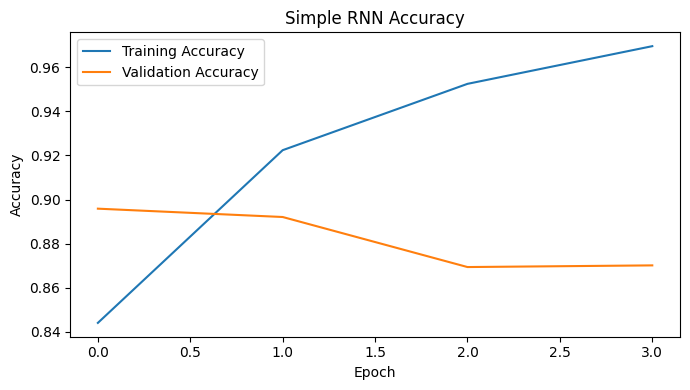

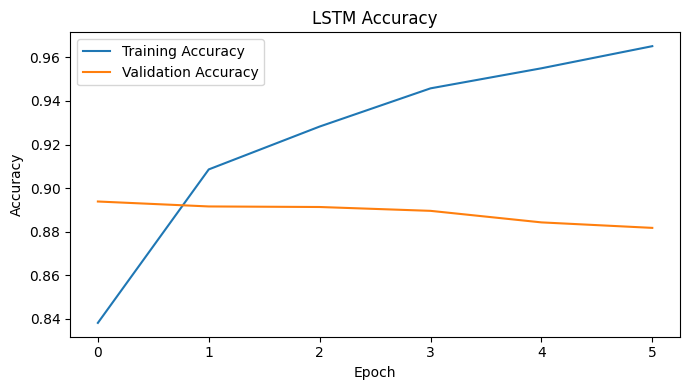

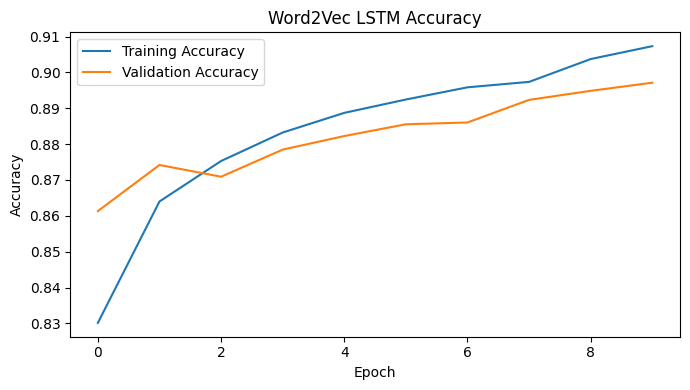

In [28]:
# Define a reusable function and plot accuracy curves for all trained models
def plot_accuracy(history, title):
    """
    Plot training and validation accuracy for a trained model.

    Parameters:
        history: Keras History object from model training.
        title (str): Title of the accuracy plot.

    Returns:
        None
    """
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_accuracy(rnn_history, "Simple RNN Accuracy")
plot_accuracy(lstm_history, "LSTM Accuracy")
plot_accuracy(word2vec_lstm_history, "Word2Vec LSTM Accuracy")

## 4.5.3.2 Plot Training and Validation Loss

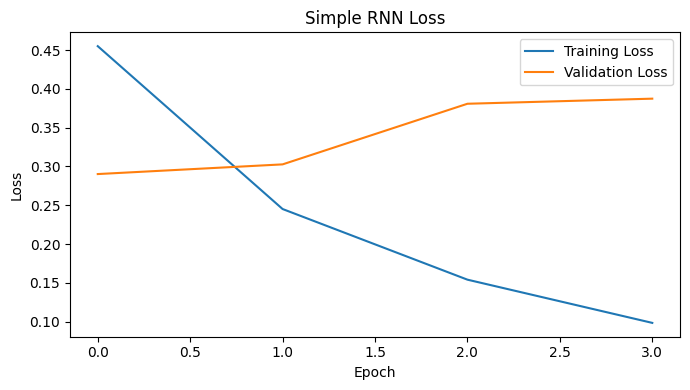

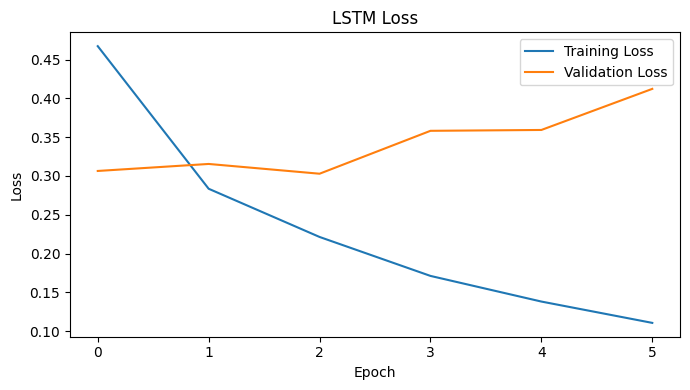

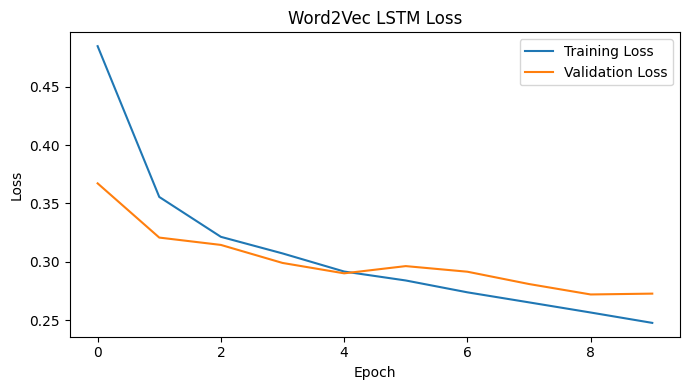

In [29]:
# Define a reusable function and plot loss curves for all trained models
def plot_loss(history, title):
    """
    Plot training and validation loss for a trained model.

    Parameters:
        history: Keras History object from model training.
        title (str): Title of the loss plot.

    Returns:
        None
    """
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_loss(rnn_history, "Simple RNN Loss")
plot_loss(lstm_history, "LSTM Loss")
plot_loss(word2vec_lstm_history, "Word2Vec LSTM Loss")

## 4.5.3.3 Accuracy, Confusion Matrix, and Classification Report

In [30]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [31]:
# Define a reusable function for evaluating classification models
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model using accuracy, confusion matrix,
    and classification report.

    Parameters:
        model: Trained Keras model.
        X_test: Padded testing sequences.
        y_test: True test labels.
        model_name (str): Name of the model.

    Returns:
        float: Accuracy score
    """

    y_prob = model.predict(X_test)
    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{model_name} Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return accuracy

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Simple RNN Accuracy: 0.8846

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.22      0.30       286
           1       0.93      0.94      0.93      3838
           2       0.77      0.86      0.81       833

    accuracy                           0.88      4957
   macro avg       0.72      0.67      0.68      4957
weighted avg       0.87      0.88      0.88      4957



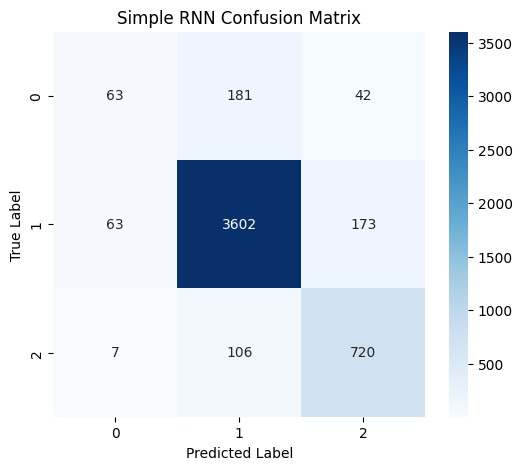

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

LSTM Accuracy: 0.8796

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.22      0.28       286
           1       0.91      0.95      0.93      3838
           2       0.81      0.78      0.80       833

    accuracy                           0.88      4957
   macro avg       0.71      0.65      0.67      4957
weighted avg       0.87      0.88      0.87      4957



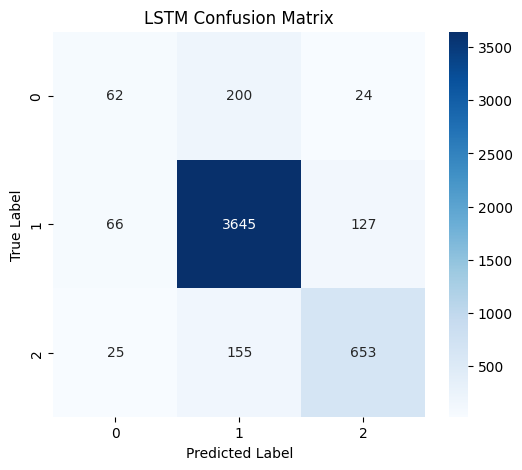

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Word2Vec LSTM Accuracy: 0.8824

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.17      0.25       286
           1       0.91      0.95      0.93      3838
           2       0.80      0.81      0.80       833

    accuracy                           0.88      4957
   macro avg       0.74      0.64      0.66      4957
weighted avg       0.87      0.88      0.87      4957



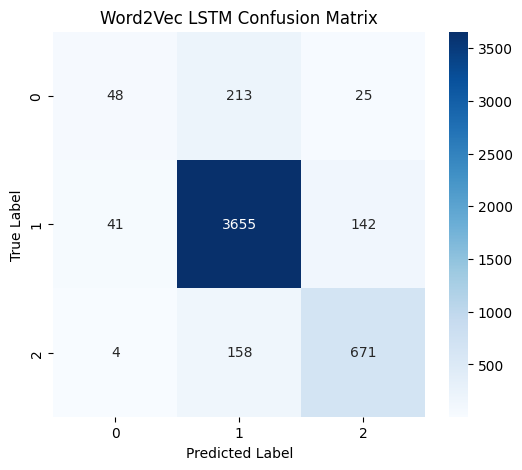

In [32]:
# Evaluate all trained models
rnn_accuracy = evaluate_model(
    rnn_model,
    X_test_pad,
    y_test,
    "Simple RNN"
)

lstm_accuracy = evaluate_model(
    lstm_model,
    X_test_pad,
    y_test,
    "LSTM"
)

word2vec_accuracy = evaluate_model(
    word2vec_lstm_model,
    X_test_pad,
    y_test,
    "Word2Vec LSTM"
)

## 4.5.3.4 Compare All Three Models

In [33]:
# Compare the accuracy of all trained models
comparison_df = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "Word2Vec LSTM"
    ],
    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        word2vec_accuracy
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy
0,Simple RNN,0.884608
2,Word2Vec LSTM,0.882389
1,LSTM,0.879564


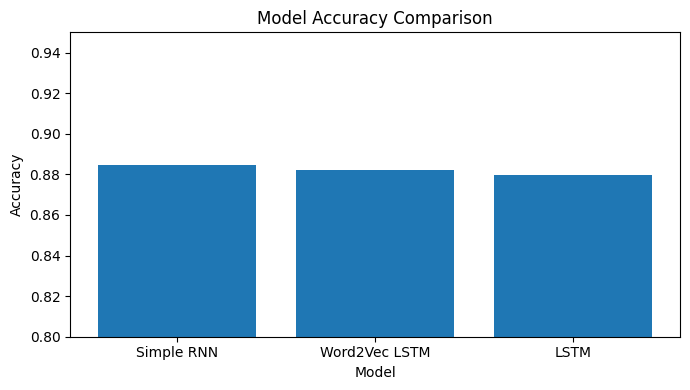

In [34]:
# Plot model accuracy comparison
plt.figure(figsize=(7, 4))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.80, 0.95)

plt.tight_layout()
plt.show()

The Simple RNN and LSTM achieved similar test accuracy, while the Word2Vec LSTM was slightly lower. However, the Word2Vec LSTM showed more stable validation loss during training, while the trainable embedding models showed stronger signs of overfitting.

# 4.5.4 Error Analysis

## 4.5.4.1 Show Incorrect Predictions

In [35]:
# Generate predictions using the LSTM model
y_prob = lstm_model.predict(X_test_pad)
y_pred = np.argmax(y_prob, axis=1)

# Create a dataframe for error analysis
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": y_pred
})

# Keep only incorrect predictions
misclassified = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

print("Number of incorrect predictions:", len(misclassified))

misclassified.head(7)

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Number of incorrect predictions: 597


,text,true_label,predicted_label
5,stfu hoe proud african american proud african ...,0,1
6,store redneck,2,0
7,honestly understand men love bash woman make f...,1,2
21,let u hang nigger,1,0
22,glenladen got life flight osu saving mess bird,2,1
23,ok faggot,1,0
29,horrible friend read text put phone something ...,2,1


## 4.5.4.2 Explain Possible Reasons for Errors

- Some errors occur because offensive words can appear in multiple classes.
- In some cases, the model predicts offensive language instead of hate speech because the text lacks enough context about the target group.
- Very short texts are difficult to classify because they contain limited information.

## 4.5.4.3 Model Complexity vs Performance

- The Simple RNN is the least complex model, but it overfitted quickly.
- The LSTM has more parameters and can learn sequence patterns better than Simple RNN.
- The Word2Vec LSTM used fewer trainable parameters because the embedding layer was frozen.
- The best choice is the LSTM with trainable embedding because it gave strong accuracy with better sequence modelling.

## 4.5.4.4 Suggested Improvements

- More balanced training data could improve hate speech detection performance.
- Additional preprocessing for slang and abbreviations may improve text understanding.
- Hyperparameter tuning could improve model generalization.
- Bidirectional LSTM or transformer-based models could be explored in future work.